In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-muted')

In [2]:
df = pd.read_csv('../data/processed/minimum_hourly_merged.csv', parse_dates=['date_local'])
df = df.sort_values('date_local').dropna(subset=['met_TMP'])

In [3]:
# naive forecast ("Last Observed Value")
# shift the temp column by 1 to "forecast" the current value using the previous hour
df['naive_forecast'] = df['met_TMP'].shift(1)

In [4]:
# linear regression
# where we use the local hour and month as predictors for temperature
df['hour_sin'] = np.sin(2 * np.pi * df['hour_local'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_local'] / 24) # wrap around 24 hours, hence trig 
df_clean = df.dropna(subset=['naive_forecast'])

X = df_clean[['hour_sin', 'hour_cos', 'month_local']]
y = df_clean['met_TMP']

# spliting the data to keep temporal order
split = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
naive_test = df_clean['naive_forecast'].iloc[split:]
test_dates = df_clean['date_local'].iloc[split:]

# fitting it into a linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [5]:
# performance metrics base off mean squared error and R2 score
metrics = { 
    "Naive MSE": mean_squared_error(y_test, naive_test),
    "Linear Regression MSE": mean_squared_error(y_test, lr_preds),
    "Linear Regression R2": r2_score(y_test, lr_preds)
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Naive MSE: 2.6274
Linear Regression MSE: 31.6084
Linear Regression R2: -1.0378


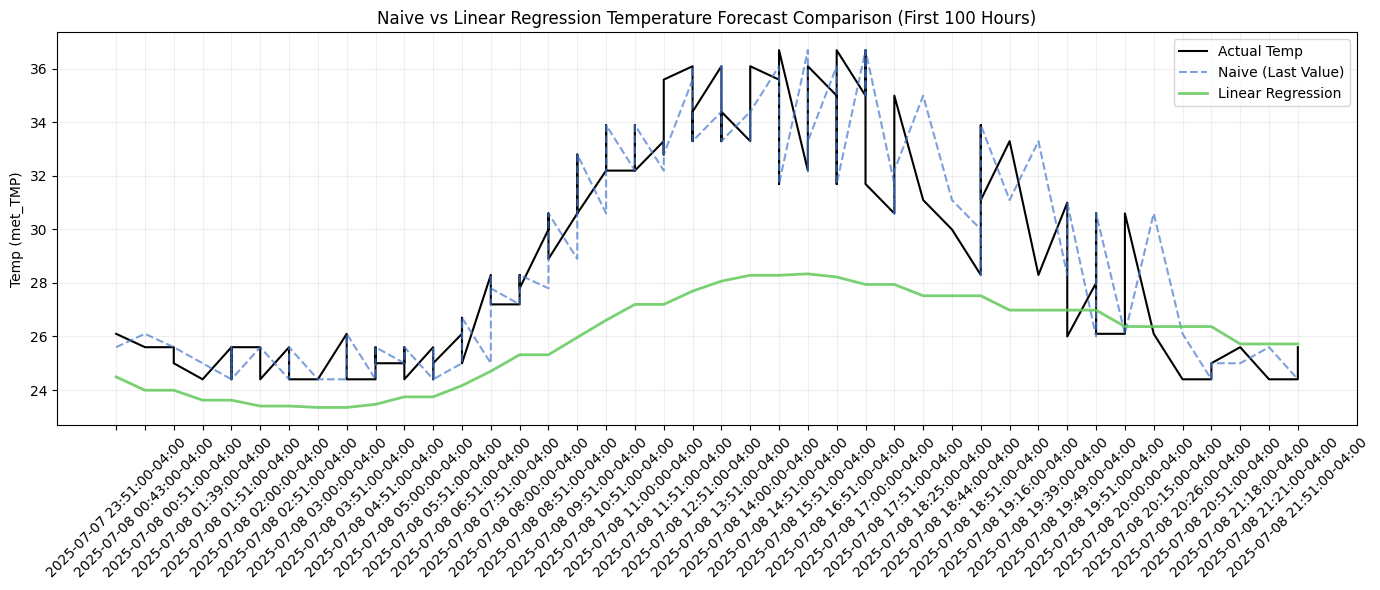

In [6]:
plt.figure(figsize=(14, 6))

# time series comparsion focusing on the first 100 hours
subset_dates = test_dates.iloc[:100]
subset_actual = y_test.iloc[:100]
subset_naive = naive_test.iloc[:100]
subset_lr = lr_preds[:100]

plt.plot(subset_dates, subset_actual, label='Actual Temp', color='black', linewidth=1.5)
plt.plot(subset_dates, subset_naive, label='Naive (Last Value)', linestyle='--', alpha=0.7)
plt.plot(subset_dates, subset_lr, label='Linear Regression', linewidth=2, alpha=0.9)

plt.title('Naive vs Linear Regression Temperature Forecast Comparison (First 100 Hours)')
plt.ylabel('Temp (met_TMP)')
plt.xticks(rotation=45) 
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

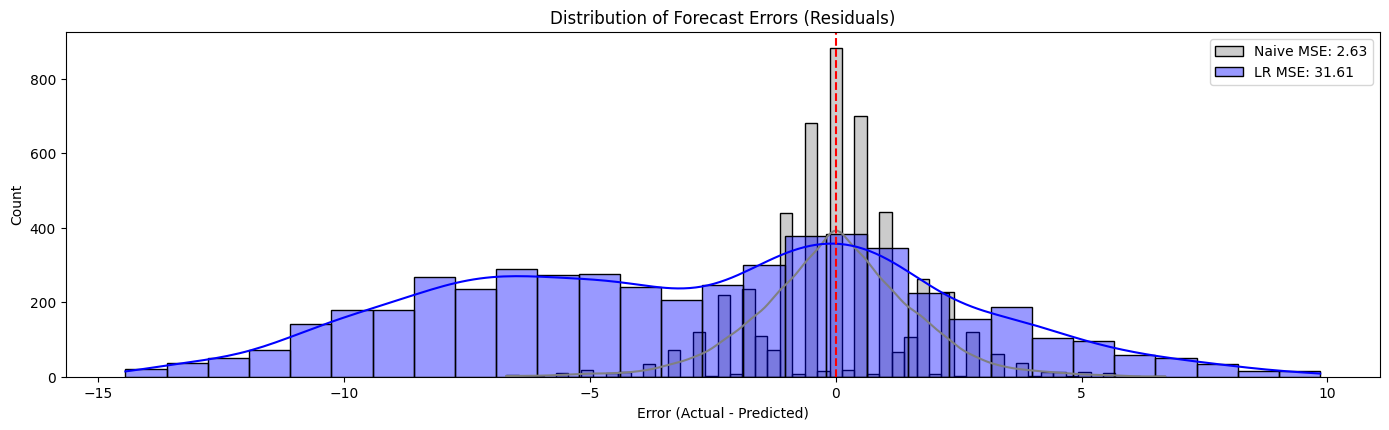

In [7]:
# another plot for  the residual/error
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 2)
naive_errors = y_test - naive_test
lr_errors = y_test - lr_preds

sns.histplot(naive_errors, color="gray", label=f"Naive MSE: {metrics['Naive MSE']:.2f}", kde=True, alpha=0.4)
sns.histplot(lr_errors, color="blue", label=f"LR MSE: {metrics['Linear Regression MSE']:.2f}", kde=True, alpha=0.4)

plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Forecast Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted)')
plt.legend()

plt.tight_layout()
plt.show()